### Lib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Data

In [12]:
# =========================
# 1. LOAD DATA
# =========================
df = pd.read_excel("C:/Users/ibuba/Kuliah/Proyek-Akhir/Aplikasi/Dataset/hasil_ocr/evaluasi model_dengan_recall.xlsx")

# =========================
# 2. LIST MODEL
# =========================
models = ["pytesseract", "donut", "keras", "llm qwen"]

# =========================
# 3. FIX FORMAT ANGKA (comma → dot)
# =========================
for m in models:
    col = f"{m}"
    df[col] = df[col].astype(str).str.replace(",", ".")
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 4. AGGREGATE RECALL PER JENIS
# =========================
result = df.groupby("jenis")[[f"{m}" for m in models]].mean()

# rename biar rapi di chart
result.columns = ["Pytesseract", "Donut", "Keras", "Qwen"]

print("=== HASIL RECALL ===")
print(result)

# =========================
# 5. SPLIT DATA
# =========================
ijazah = result.loc["ijazah"]
sertifikat = result.loc["sertifikat"]

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# FIX FORMAT ANGKA
# =========================
for m in models:
    col = f"{m}"
    df[col] = df[col].astype(str).str.replace(",", ".")
    df[col] = pd.to_numeric(df[col], errors="coerce")

=== HASIL RECALL ===
            Pytesseract  Donut  Keras  Qwen
jenis                                      
ijazah              NaN    NaN    NaN   NaN
sertifikat          NaN    NaN    NaN   NaN


### evaluasi

In [ ]:
# =========================
# PLOT IJAZAH RECALL
# =========================

# =========================
# AGGREGATE
# =========================
result = df.groupby("jenis")[[f"recall_{m}" for m in models]].mean()

# ambil ijazah
ijazah = result.loc["ijazah"]

# rename biar clean
labels = ["pytesseract", "donut", "keras", "llm qwen"]
values = ijazah.values

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

plt.title("Rata-rata Keyword Recall (Ijazah)")
plt.ylabel("Recall Score (0.0 - 1.0)")

# =========================
# ADD PERCENT TEXT DI ATAS BAR
# =========================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height*100:.1f}%",
        ha='center',
        fontsize=10
    )

plt.ylim(0, 1.1)
plt.tight_layout()

plt.savefig("ijazah_recall_styled.png")
plt.show()

TypeError: agg function failed [how->mean,dtype->object]

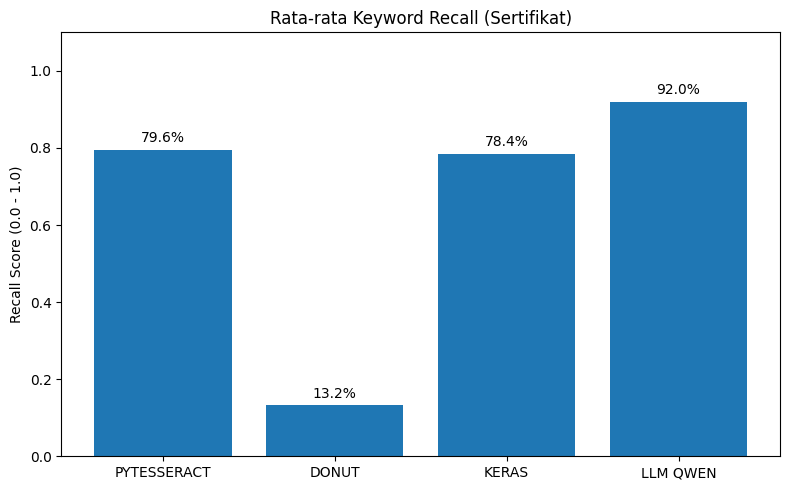

In [5]:
# =========================
# PLOT
# =========================

# =========================
# AGGREGATE
# =========================
result = df.groupby("jenis")[[f"recall_{m}" for m in models]].mean()

# rename biar clean
labels = ["PYTESSERACT", "DONUT", "KERAS", "LLM QWEN"]
values = sertifikat.values

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

plt.title("Rata-rata Keyword Recall (Sertifikat)")
plt.ylabel("Recall Score (0.0 - 1.0)")

# =========================
# ADD PERCENT TEXT DI ATAS BAR
# =========================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height*100:.1f}%",
        ha='center',
        fontsize=10
    )

plt.ylim(0, 1.1)
plt.tight_layout()

plt.savefig("sertifikat_recall_styled.png")
plt.show()